# Una sola metilación apaga la enzima

Una marca química diminuta — un grupo metilo en el carbono 5 de una citosina del ADN — basta para que la herramienta más usada en edición genómica deje de cortar. ¿Y si esa "debilidad" pudiera convertirse en una ventaja terapéutica?

📄 **Paper:** [Molecular basis for methylation-sensitive editing by Cas9](https://doi.org/10.1038/s41586-026-10384-z) · *Nature, 2026*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-22-cas9-metilacion-pam/notebook.ipynb)

🎬 **Video:** [Pendiente]

## Lo que midieron

ThermoCas9 es una variante de Cas9 (de la bacteria *Geobacillus thermodenitrificans*) que necesita una secuencia corta de ADN llamada **PAM** para cortar — algo como una "matrícula de aparcamiento" que la enzima reconoce antes de actuar. Y aquí lo raro: si una citosina específica del PAM está **metilada** (con un grupo metilo en su carbono 5, una marca epigenética común en mamíferos), la enzima pierde casi toda su actividad.

Para probarlo atacaron por tres frentes: ensayos *in vitro* con ADN sintético, edición en células humanas con distintos paisajes de metilación, y cuatro fotografías a escala atómica por crio-microscopía electrónica del bolsillo que reconoce el PAM.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
KI_RATIO_OBSERVADO = 12       # cuántas veces más fuerte se une al ADN no metilado
INDEL_UMBRAL = 5              # % de edición que consideramos "actividad real"
COLOR_NOMET = "#2563EB"       # azul CaM — ADN sin metilar
COLOR_MET = "#DC2626"         # rojo — ADN metilado
COLOR_CANCER = "#7C3AED"      # violeta — línea celular cancerosa
COLOR_NORMAL = "#059669"      # verde — línea celular normal
FUENTE = "Fuente: Pacesa et al. (2026), Nature | Datos: Supplementary del paper"

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle",
            style_file,
        )
plt.style.use(style_file)

os.makedirs("figuras", exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de datos
# ══════════════════════════════════════════════════════════════
indel = pd.read_csv("datos/indel_cellular.csv")
ki = pd.read_csv("datos/ki_oligos.csv")
construct = pd.read_csv("datos/construct_editing.csv")
cryoem = pd.read_csv("datos/cryoem_resolutions.csv")

print(f"indel: {len(indel)} mediciones · {indel['site'].nunique()} sitios × {indel['cell_line'].nunique()} líneas")
print(f"ki: {len(ki)} condiciones (ratio metilado/no metilado = {ki['ki_nm'].iloc[1]/ki['ki_nm'].iloc[0]:.1f}×)")
print(f"construct: {len(construct)} condiciones (MCF-7 cáncer vs MCF-10A normal)")
print(f"cryoem: {len(cryoem)} estructuras · resolución {cryoem['resolution_angstrom'].min()}–{cryoem['resolution_angstrom'].max()} Å")


indel: 8 mediciones · 4 sitios × 2 líneas
ki: 2 condiciones (ratio metilado/no metilado = 12.0×)
construct: 6 condiciones (MCF-7 cáncer vs MCF-10A normal)
cryoem: 4 estructuras · resolución 2.2–3.5 Å


## Aquí está.

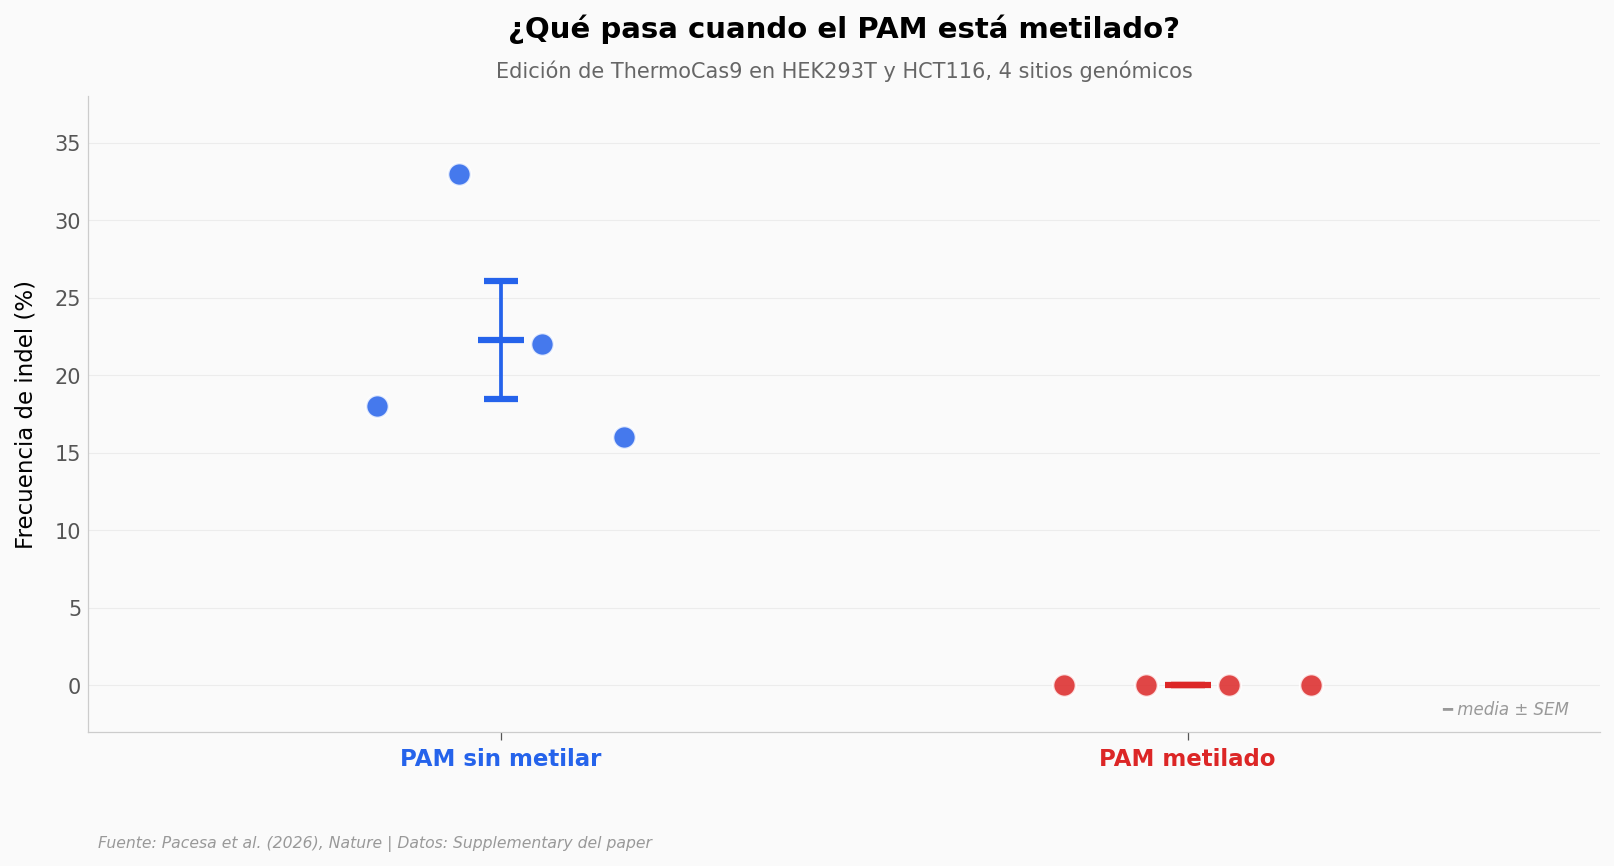

In [2]:
# Indel por estado de metilación del PAM (4 sitios × 2 líneas celulares)
fig, ax = plt.subplots(figsize=(13, 5.5))

np.random.seed(42)
nomet = indel[indel["pam_methylation_status"] == "unmethylated"]["indel_pct"].values
met = indel[indel["pam_methylation_status"] == "methylated"]["indel_pct"].values

x_nomet = np.linspace(-0.18, 0.18, len(nomet))
np.random.shuffle(x_nomet)
x_met = np.linspace(-0.18, 0.18, len(met))
np.random.shuffle(x_met)

ax.scatter(x_nomet, nomet, color=COLOR_NOMET, s=120, alpha=0.85,
           edgecolors="white", linewidths=1.2, zorder=5)
ax.scatter(1 + x_met, met, color=COLOR_MET, s=120, alpha=0.85,
           edgecolors="white", linewidths=1.2, zorder=5)

mean_nomet, sem_nomet = nomet.mean(), nomet.std(ddof=1) / np.sqrt(len(nomet))
mean_met = met.mean()
sem_met = met.std(ddof=1) / np.sqrt(len(met)) if met.std() > 0 else 0
ax.errorbar(0, mean_nomet, yerr=sem_nomet, fmt="_", color=COLOR_NOMET,
            markersize=22, markeredgewidth=3, capsize=8, capthick=2, zorder=6)
ax.errorbar(1, mean_met, yerr=sem_met, fmt="_", color=COLOR_MET,
            markersize=22, markeredgewidth=3, capsize=8, capthick=2, zorder=6)

ax.set_xticks([0, 1])
ax.set_xticklabels(["PAM sin metilar", "PAM metilado"], fontsize=11, fontweight="bold")
ax.get_xticklabels()[0].set_color(COLOR_NOMET)
ax.get_xticklabels()[1].set_color(COLOR_MET)
ax.set_ylabel("Frecuencia de indel (%)", fontsize=11)
ax.set_ylim(-3, 38)
ax.set_xlim(-0.6, 1.6)

ax.set_title("¿Qué pasa cuando el PAM está metilado?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Edición de ThermoCas9 en HEK293T y HCT116, 4 sitios genómicos",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.text(0.98, 0.02, "━ media ± SEM", transform=ax.transAxes,
        fontsize=8, color="#999999", ha="right", va="bottom", style="italic")

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/indel_methylation.png", dpi=200, bbox_inches="tight")
plt.show()


## Lectura guiada

Lo que llama la atención no es que la edición baje. Es que **se apaga**. Cuando el PAM está metilado, ThermoCas9 deja de cortar — la frecuencia de indel cae a cero en los cuatro sitios probados, sin importar la línea celular. Sin metilación la edición oscila entre el 16% y el 33%, valores típicos para Cas9 en cultivo.

El detalle clave: el equipo eligió pares de sitios donde la **secuencia es idéntica entre líneas celulares**. Lo único que cambia es el estado de metilación. Eso elimina el efecto de la cromatina, la accesibilidad y la secuencia local — la metilación es el único sospechoso.

## ¿Qué tan fuerte es la preferencia?

Para cuantificar el efecto sin la complicación del entorno celular, midieron *in vitro* la constante de inhibición (Ki) — un número que dice cuánta concentración de un competidor se necesita para frenar a la enzima. Ki bajo = competidor fuerte; Ki alto = competidor débil.

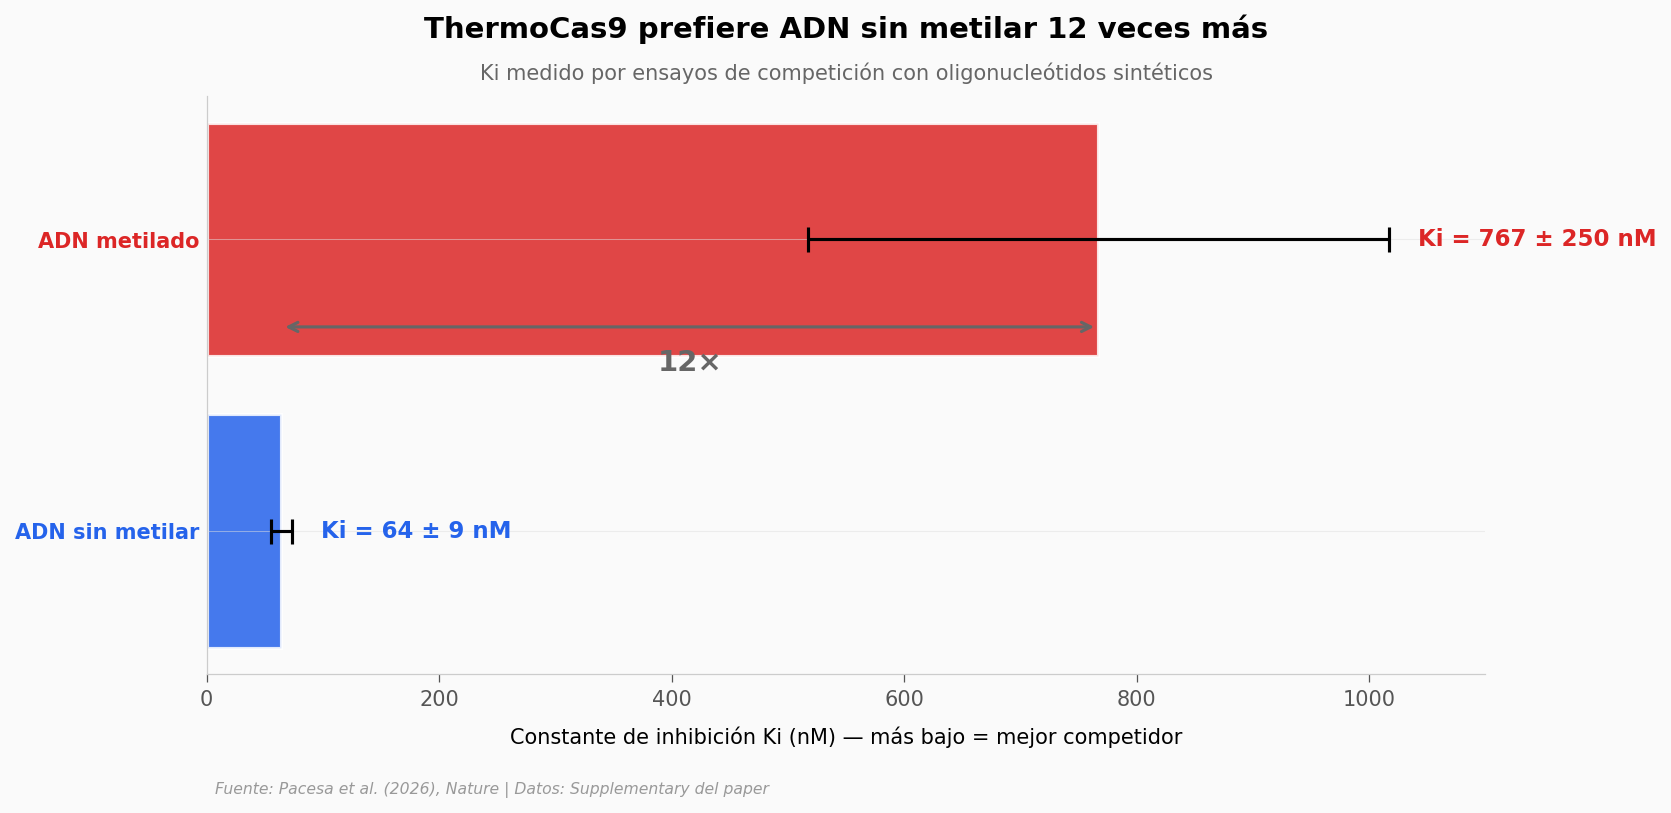

In [3]:
# Ki: ADN sin metilar vs metilado (in vitro)
fig, ax = plt.subplots(figsize=(11, 5))

labels = ["ADN sin metilar", "ADN metilado"]
values = ki["ki_nm"].values
errors = ki["ki_se_nm"].values
colors = [COLOR_NOMET, COLOR_MET]

bars = ax.barh(labels, values, xerr=errors, color=colors, alpha=0.85,
               edgecolor="white", linewidth=1.5,
               error_kw={"capsize": 6, "capthick": 1.5, "elinewidth": 1.5})

for i, (v, e) in enumerate(zip(values, errors)):
    ax.text(v + e + 25, i, f"Ki = {v} ± {e} nM",
            fontsize=11, fontweight="bold", color=colors[i], va="center")

ax.set_xlabel("Constante de inhibición Ki (nM) — más bajo = mejor competidor", fontsize=10)
ax.set_xlim(0, 1100)
for tick, color in zip(ax.get_yticklabels(), colors):
    tick.set_color(color)
    tick.set_fontweight("bold")

ax.set_title("ThermoCas9 prefiere ADN sin metilar 12 veces más",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Ki medido por ensayos de competición con oligonucleótidos sintéticos",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

ax.annotate("", xy=(767, 0.7), xytext=(64, 0.7),
            arrowprops=dict(arrowstyle="<->", color="#666666", lw=1.5))
ax.text((64 + 767) / 2, 0.55, "12×", fontsize=14, fontweight="bold",
        color="#666666", ha="center")

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/ki_oligos.png", dpi=200, bbox_inches="tight")
plt.show()


## La grieta terapéutica

Si la enzima distingue ADN metilado de ADN no metilado, entonces edita preferentemente células que tienen sus genes diana **hipo-metilados**. Y eso es justo lo que pasa con ciertos genes en cáncer de mama: en tumores luminales, *GATA3* y *ESR1* — genes que controlan la identidad celular — pierden su metilación normal mientras siguen metilados en células sanas.

El equipo lo probó en una pareja clásica del laboratorio: MCF-7 (línea de cáncer de mama, hipometilada en estos sitios) y MCF-10A (línea epitelial mamaria normal, metilada).

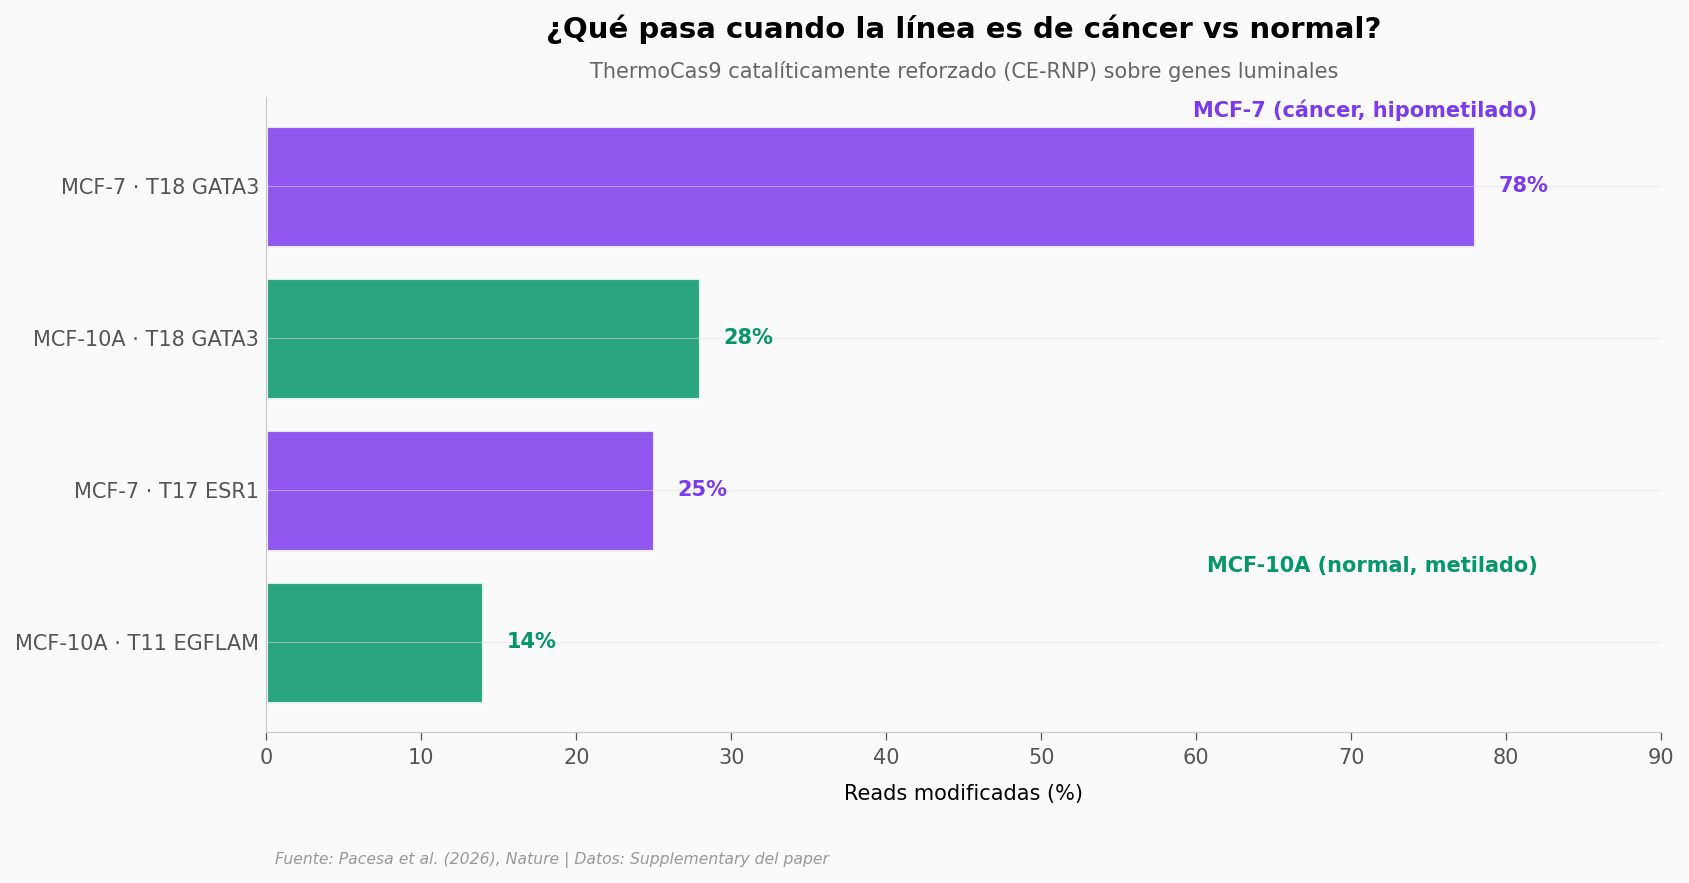

In [4]:
# Edición en MCF-7 (cáncer) vs MCF-10A (normal) con ThermoCas9 catalíticamente reforzado (CE-RNP)
fig, ax = plt.subplots(figsize=(12, 5.5))

df = construct[(construct["construct"] == "CE_RNP") & construct["pct"].notna()].copy()

df["label"] = df["cell_line"] + " · " + df["site"]
df = df.sort_values("pct", ascending=True).reset_index(drop=True)

df["color"] = df["cell_line"].map({"MCF-7": COLOR_CANCER, "MCF-10A": COLOR_NORMAL})

ax.barh(df["label"], df["pct"], color=df["color"], alpha=0.85,
        edgecolor="white", linewidth=1.5)

for i, (lab, p) in enumerate(zip(df["label"], df["pct"])):
    ax.text(p + 1.5, i, f"{p:.0f}%", fontsize=10, fontweight="bold",
            color=df["color"].iloc[i], va="center")

ax.set_xlabel("Reads modificadas (%)", fontsize=10)
ax.set_xlim(0, 90)

ax.text(82, len(df) - 0.5, "MCF-7 (cáncer, hipometilado)", fontsize=10,
        color=COLOR_CANCER, fontweight="bold", ha="right", va="center")
ax.text(82, 0.5, "MCF-10A (normal, metilado)", fontsize=10,
        color=COLOR_NORMAL, fontweight="bold", ha="right", va="center")

ax.set_title("¿Qué pasa cuando la línea es de cáncer vs normal?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "ThermoCas9 catalíticamente reforzado (CE-RNP) sobre genes luminales",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/mcf7_vs_mcf10a.png", dpi=200, bbox_inches="tight")
plt.show()


## ¿Cómo lo ven a escala atómica?

Para entender el mecanismo a fondo había que ir a escala atómica. Cuatro estructuras de crio-microscopía electrónica, la mejor a 2,2 Å — nítida como para ver el grupo metilo individual y el aminoácido que lo rechaza.

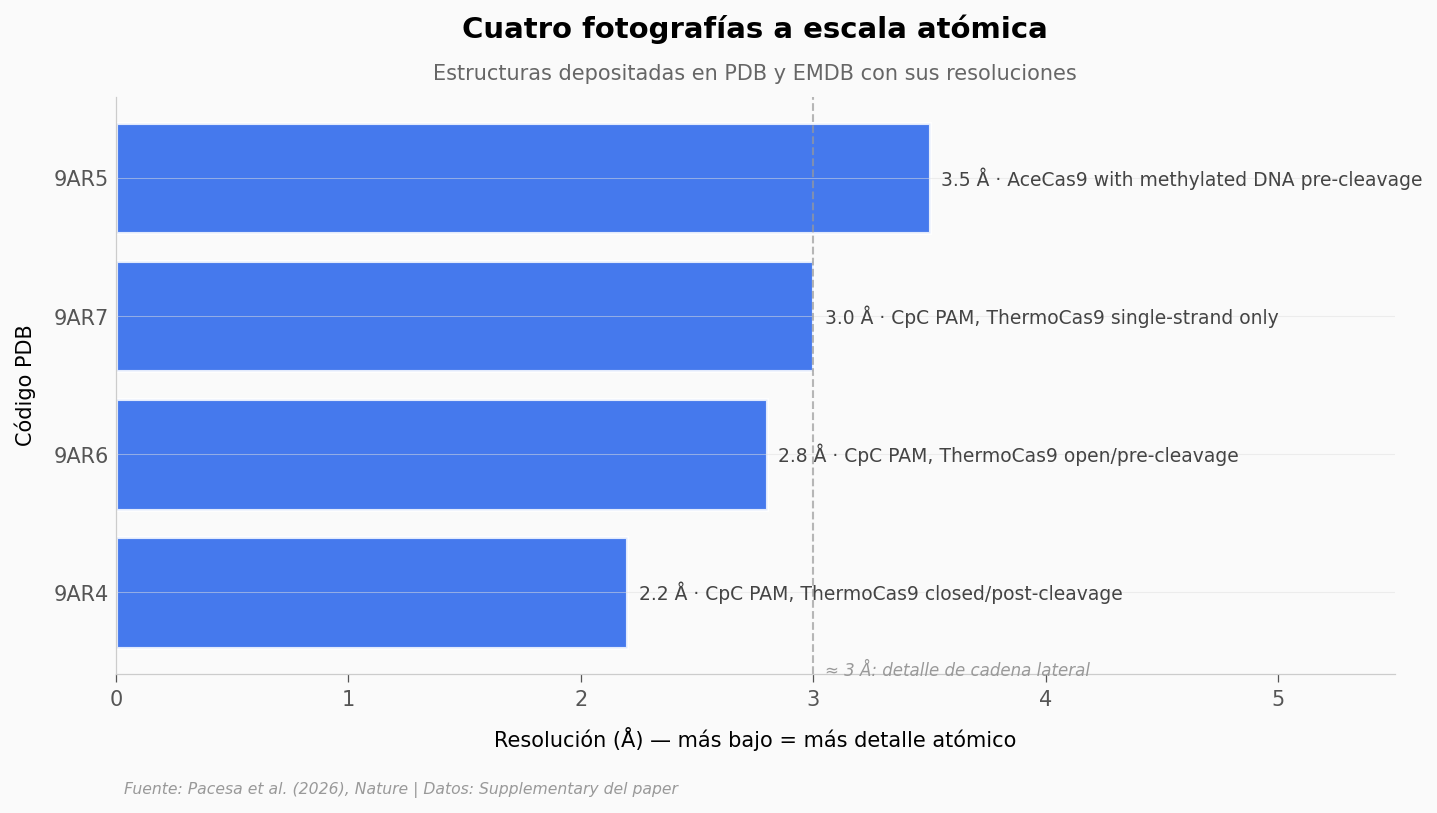

In [5]:
# Resolución de las 4 estructuras de crio-EM
fig, ax = plt.subplots(figsize=(11, 5))

df = cryoem.sort_values("resolution_angstrom").copy().reset_index(drop=True)

ax.barh(df["pdb_id"], df["resolution_angstrom"],
        color=COLOR_NOMET, alpha=0.85, edgecolor="white", linewidth=1.5)

for i, (pdb, res, desc) in enumerate(zip(df["pdb_id"], df["resolution_angstrom"], df["description"])):
    ax.text(res + 0.05, i, f"{res} Å · {desc}",
            fontsize=9, color="#444444", va="center")

ax.set_xlabel("Resolución (Å) — más bajo = más detalle atómico", fontsize=10)
ax.set_ylabel("Código PDB", fontsize=10)
ax.set_xlim(0, 5.5)

ax.axvline(x=3.0, color="#999999", linewidth=1, linestyle="--", alpha=0.7)
ax.text(3.05, -0.6, "≈ 3 Å: detalle de cadena lateral",
        fontsize=8, color="#999999", style="italic")

ax.set_title("Cuatro fotografías a escala atómica",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Estructuras depositadas en PDB y EMDB con sus resoluciones",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/cryoem_resolutions.png", dpi=200, bbox_inches="tight")
plt.show()


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| La metilación del PAM apaga la edición | ✅ | 4/4 sitios metilados → 0% indel; 4/4 sitios sin metilar → 16-33%. Diseño cruzado por línea celular controla efectos de cromatina. |
| ThermoCas9 prefiere 12× ADN sin metilar *in vitro* | ✅ | Ki = 64 ± 9 nM (sin metilar) vs 767 ± 250 nM (metilado). El error en el metilado es alto (32% relativo) — el ratio es robusto pero el valor absoluto tiene incertidumbre. |
| MCF-7 (cáncer) edita más que MCF-10A (normal) | ⚠️ | MCF-7 GATA3 alcanza 78%, MCF-10A 14-28%. Sin embargo, el control en MCF-10A no es 0% — la ventana terapéutica existe pero no es absoluta. |
| 4 estructuras de crio-EM con resoluciones 2,2-3,5 Å | ✅ | Depositadas en PDB (9AR4-9AR7) y EMDB (43769-43772). La de 2,2 Å permite ver el grupo metilo. |
| Aplicación clínica directa | ⚠️ | El paper enmarca esto como *muestra potencial* para terapias. No hay datos *in vivo* ni en pacientes. |

> **Limitaciones del análisis:** N pequeño (4 sitios, 2 líneas celulares); no recalculamos test estadístico — el paper reporta two-way ANOVA con corrección Sidak (p<0.0001). Los Ki tienen errores estándar grandes (especialmente en metilado: ±250 sobre 767, 32% relativo). Las líneas celulares MCF-7 y MCF-10A difieren en más cosas que la metilación (genoma, contexto).

## Ahora tú

Tres preguntas para cacharrear con los datos:

1. **¿Cuál sería el ratio de Ki si los errores estándar fueran sumados (peor caso)?** Pista: usa el percentil más alto del intervalo metilado y el más bajo del no metilado.
2. **¿Hay alguna ventaja consistente entre MCF-7 y MCF-10A para los sitios donde ambas tienen datos?** Pista: filtra `construct[construct["construct"] == "CE_RNP"]` y compara por sitio.
3. **¿La diferencia entre HEK293T y HCT116 es mayor que la diferencia metilado/no metilado?** Pista: agrupa `indel` por `cell_line` y compara las medias.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ratio en el peor caso (Ki metilado más bajo / Ki no metilado más alto)
unmet = ki[ki["oligo_type"] == "unmethylated_oligo"].iloc[0]
methy = ki[ki["oligo_type"] == "target_strand_methylated_oligo"].iloc[0]

ki_unmet_alto = unmet["ki_nm"] + unmet["ki_se_nm"]
ki_met_bajo = methy["ki_nm"] - methy["ki_se_nm"]

print(f"Ki sin metilar (cota alta): {ki_unmet_alto} nM")
print(f"Ki metilado (cota baja):    {ki_met_bajo} nM")
print(f"Ratio en el peor caso:      {ki_met_bajo/ki_unmet_alto:.1f}×")
print(f"Ratio reportado (medias):   12.0×")
print()
print("Incluso en el peor escenario, la preferencia se mantiene clara —")
print("aunque pasa de 12× a un múltiplo más modesto.")


Ki sin metilar (cota alta): 73 nM
Ki metilado (cota baja):    517 nM
Ratio en el peor caso:      7.1×
Ratio reportado (medias):   12.0×

Incluso en el peor escenario, la preferencia se mantiene clara —
aunque pasa de 12× a un múltiplo más modesto.


## Fuentes

**Paper**: [Molecular basis for methylation-sensitive editing by Cas9](https://doi.org/10.1038/s41586-026-10384-z)  
*Nature, 2026-04-15*

**Datos**: Supplementary Information, Extended Data Tables y estructuras depositadas en [PDB](https://www.rcsb.org/) (9AR4–9AR7) y [EMDB](https://www.ebi.ac.uk/emdb/) (EMD-43769 a EMD-43772)

*14 afirmaciones verificadas contra estas fuentes*

---

📂 **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia: CC BY 4.0
🔬 **Notebook reproducible:** `jupyter execute notebook.ipynb`